# BenchmarkResults: Loading, Filtering, and Plotting Results

This notebook demonstrates the `BenchmarkResults` class for loading and filtering computational free energy results.

Key features:
- Load results with `get_benchmark_results()`
- Filter by tags, systems, and metadata
- Use comparison operators with pint Quantities (e.g., `dg='>1.0 kilocalories_per_mole'`)
- Generate FEMaps with lazy `.dg_femaps` and `.ddg_femaps` properties
- Plot predicted vs experimental values with cinnabar

## Setup

In [1]:
from openfe_benchmarks.results import get_benchmark_results, filter_results
from cinnabar import plotting
import matplotlib.pyplot as plt

%matplotlib inline

## Load a Submission

We'll load an RBFE submission using the `get_benchmark_results()` factory function.

In [2]:
# Load results
results = get_benchmark_results("2026-03-18-openmm-840-qa-testing")
print(results)

BenchmarkResults(submission_id='2026-03-18-openmm-840-qa-testing', calculation_type='rbfe')


## Explore Metadata

In [3]:
print(f"Submission ID: {results.submission_id}")
print(f"Title: {results.title}")
print(f"Calculation Type: {results.calculation_type}")
print(f"Tags: {', '.join(results.tags)}")
print(f"Date: {results.date}")
print(f"OpenFE Version: {results.openfe_version}")
print(f"Force field: {results.forcefield}")

Submission ID: 2026-03-18-openmm-840-qa-testing
Title: OpenFE RBFE - Multi-set Benchmark (2 sets, 5 systems) - 2026-03-18-openmm-840-qa-testing
Calculation Type: rbfe
Tags: rbfe, ff14SB, phosaa10, tip3p_HFE_multivalent, tip3p_standard, charge_annihilation_set, egfr, irak4_s2, irak4_s3, jacs_set, p38, tyk2, nagl_openff-gnn-am1bcc-1.0.0.pt, charge_change, benchmark, openfe, openmm-840
Date: 2026-06-19
OpenFE Version: 1.9.1
Force field: ['ff14SB', 'phosaa10', 'tip3p_HFE_multivalent', 'tip3p_standard']


## Raw Results Structure

The `raw_results` attribute contains the computational data as nested dictionaries.

In [4]:
print(f"Raw results keys: {list(results.raw_results.keys())}")
print(f"\nNumber of dg results: {len(results.raw_results.get('dg', []))}")
print(f"Number of ddg results: {len(results.raw_results.get('ddg', []))}")

# Show structure of one ddg result
if "ddg" in results.raw_results and results.raw_results["ddg"]:
    sample_result = results.raw_results["ddg"][0]
    print(f"\nSample ddg result keys: {list(sample_result.keys())}")
    print(
        f"System: {sample_result.get('system_group')}/{sample_result.get('system_name')}"
    )
    print(
        f"Ligand pair: {sample_result.get('ligand_i_name')} -> {sample_result.get('ligand_j_name')}"
    )
    print(f"DDG: {sample_result.get('ddg')}")

Raw results keys: ['dg', 'ddg']

Number of dg results: 56
Number of ddg results: 80

Sample ddg result keys: ['ligand_a', 'ligand_b', 'system_group', 'system_name', 'ddg', 'ddg_uncertainty', 'dgs_complex', 'dgs_solvent', 'complex_smallest_mbar_overlaps', 'complex_smallest_replica_mixing', 'solvent_smallest_mbar_overlaps', 'solvent_smallest_replica_mixing']
System: jacs_set/tyk2
Ligand pair: None -> None
DDG: -0.31190011815882457 kilocalories_per_mole


## Filtering Examples

The `filter_results()` function supports various filtering operations.

### Filter by Tag (Single)

In [5]:
rbfe_results = filter_results(results, tags="rbfe")
print(f"Results with 'rbfe' tag: {len(rbfe_results)}")

Results with 'rbfe' tag: 136


### Filter by Multiple Tags (AND logic, default)

In [6]:
# Must have ALL specified tags
validated_results = filter_results(results, tags=["rbfe", "openfe"])
print(f"Results with BOTH 'rbfe' AND 'openfe' tags: {len(validated_results)}")

Results with BOTH 'rbfe' AND 'openfe' tags: 136


### Filter by Multiple Tags (OR logic)

In [7]:
# Must have ANY of the specified tags
any_calc_results = filter_results(results, tags=["rbfe", "asfe"], tags_mode="any")
print(f"Results with 'rbfe' OR 'asfe' tag: {len(any_calc_results)}")

Results with 'rbfe' OR 'asfe' tag: 136


### Filter by System Group

In [8]:
jacs_results = filter_results(results, system_group="jacs_set")
print(f"Results from jacs_set: {len(jacs_results)}")

Results from jacs_set: 123


### Filter with Wildcard

In [9]:
tyk2_results = filter_results(results, system_name="*tyk2*")
print(f"Results with 'tyk2' in system name: {len(tyk2_results)}")

Results with 'tyk2' in system name: 38


### Filter with OR Logic (List Values for Non-Tags)

In [10]:
# Match if system_name is tyk2 OR thrombin
multi_system = filter_results(results, system_name=["tyk2", "thrombin"])
print(f"Results from tyk2 OR thrombin: {len(multi_system)}")

Results from tyk2 OR thrombin: 38


### Filter with NOT Logic (exclude_ prefix)

In [11]:
# Exclude results with 'deprecated' tag
no_deprecated = filter_results(results, exclude_tags="deprecated")
print(f"Results without 'deprecated' tag: {len(no_deprecated)}")

Results without 'deprecated' tag: 136


### Complex Filter: Combine Multiple Conditions

In [12]:
# Combine tags AND + system OR + exclude
complex_filtered = filter_results(
    results,
    tags=["rbfe", "openfe"],  # has BOTH rbfe AND openfe
    system_name=["tyk2", "thrombin"],  # AND (tyk2 OR thrombin)
    exclude_tags=["test"],  # AND NOT test
)
print(f"Complex filtered results: {len(complex_filtered)}")

Complex filtered results: 38


### Filter by Nested Protocol Settings

In [13]:
# Use double underscore (__) for nested field access
# Note: This example may not match anything depending on the submission structure
nested_results = filter_results(results, protocol_settings__lambda_windows="11")
print(f"Results with lambda_windows='11': {len(nested_results)}")

Results with lambda_windows='11': 0


## Comparison Operators with Pint Quantities

The new pint Quantity comparison feature allows filtering by magnitude with automatic unit conversion.

**Note**: Direct comparison operators in `filter_results()` are demonstrated here for documentation purposes. The implementation handles unit conversion automatically when comparing pint Quantity objects.

In [14]:
# Example: Filter for high magnitude results
# In practice, you would filter the raw dg/ddg values directly
if "ddg" in results.raw_results:
    ddg_results = results.raw_results["ddg"]

    # Manual filtering showing pint Quantity comparison
    # The comparison automatically handles unit conversion
    high_magnitude = [
        r
        for r in ddg_results
        if abs(r.get("ddg", 0).magnitude) > 1.0  # magnitude in kilocalories_per_mole
    ]

    print(f"\nResults with |ddg| > 1.0 kcal/mol: {len(high_magnitude)}")
    print(f"Total ddg results: {len(ddg_results)}")

    # Show a few examples
    if high_magnitude:
        print("\nExample high-magnitude results:")
        for r in high_magnitude[:3]:
            print(
                f"  {r.get('ligand_i_name')} -> {r.get('ligand_j_name')}: {r.get('ddg')}"
            )


Results with |ddg| > 1.0 kcal/mol: 36
Total ddg results: 80

Example high-magnitude results:
  None -> None: 1.102046405017669 kilocalories_per_mole
  None -> None: -1.6725148955864118 kilocalories_per_mole
  None -> None: 2.3959460144061424 kilocalories_per_mole


## FEMap Generation

FEMaps are generated lazily using the `.ddg_femaps` and `.dg_femaps` properties.

In [15]:
# Access ddg_femaps (first access may be slow)
print("Generating FEMaps...")
ddg_femaps = results.ddg_femaps

print(f"\nGenerated {len(ddg_femaps)} FEMaps:")
for (system_group, system_name), femap in ddg_femaps.items():
    # Use to_legacy_graph() to get the networkx graph
    leg_graph = femap.to_legacy_graph()
    n_edges = len(leg_graph.edges())
    print(f"  - {system_group}/{system_name}: {n_edges} edges")

2026-08-18 19:46:00 - openfe_benchmarks.results._benchmark_results - INFO - Computing FEMaps for ddg results - first access may be slow
2026-08-18 19:46:00 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'tyk2' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-08-18 19:46:00 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'p38' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-08-18 19:46:00 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'irak4_s2' from benchmark set 'charge_annihilation_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-08-18 19:46:00 - openfe_b

Generating FEMaps...

Generated 5 FEMaps:
  - jacs_set/tyk2: 22 edges
  - jacs_set/p38: 51 edges
  - charge_annihilation_set/irak4_s2: 3 edges
  - charge_annihilation_set/irak4_s3: 2 edges
  - charge_annihilation_set/egfr: 2 edges


/Users/jenniferclark/mamba/envs/openfe-benchmarks-test/lib/python3.13/site-packages/cinnabar/femap.py:556: UserWarning: Graph is not connected enough to compute absolute values
  warnings.warn("Graph is not connected enough to compute absolute values")


## Plotting Example

Use cinnabar to plot predicted vs experimental for one system.

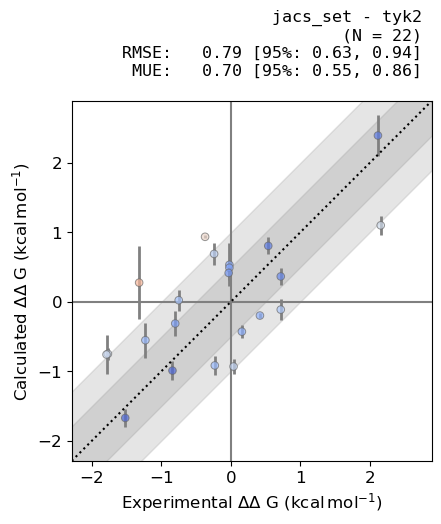

<Figure size 640x480 with 0 Axes>


Plotted jacs_set/tyk2 with 22 edges


In [16]:
# Plot the first system
if ddg_femaps:
    (system_group, system_name), femap = list(ddg_femaps.items())[0]

    # Create the plot
    leg_graph = femap.to_legacy_graph()
    fig = plotting.plot_DDGs(
        graph=leg_graph,
        title=f"{system_group} - {system_name}",
        figsize=6,
        scatter_kwargs={"s": 30, "marker": "o", "alpha": 0.7},
    )
    plt.tight_layout()
    plt.show()

    print(f"\nPlotted {system_group}/{system_name} with {len(leg_graph.edges())} edges")

## Summary

This notebook demonstrated:

1. **Loading results** with `get_benchmark_results()`
2. **Filtering** with various conditions:
   - Single and multiple tags (AND/OR logic)
   - System name and group
   - Wildcards and NOT logic
   - Nested protocol settings
3. **Pint Quantity comparison** for filtering by magnitude
4. **Lazy FEMap generation** with `.ddg_femaps` property
5. **Plotting** with cinnabar

Next steps:
- Explore other submissions with different calculation types (ASFE, RBFE)
- Use filtering to focus on specific systems or conditions
- Combine with statistical analysis for benchmark comparisons